# ECO491: Homework 6

In [85]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import os

In [86]:
# Helper functions
def norm_cdf(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def garman_kohlhagen_call(S, K, T, rd, rf, sigma):
    volT = sigma * math.sqrt(T)
    d1 = (math.log(S / K) + (rd - rf + 0.5 * sigma**2) * T) / volT
    d2 = d1 - volT
    return S * math.exp(-rf*T) * norm_cdf(d1) - K * math.exp(-rd*T) * norm_cdf(d2)

## Problem 2: Backtesting Value at Risk

In [87]:
ap = pd.read_excel("../data/Apple.xlsx")
ap["Date"] = pd.to_datetime(ap["Date"])
ap = ap.sort_values("Date")
ap["R"] = np.log(ap["Adj Close"]).diff()
ap = ap.dropna()
ap = ap[(ap["Date"] >= "2015-10-13") & (ap["Date"] <= "2021-10-08")]

returns = ap["R"].to_numpy()
dates = ap["Date"].to_numpy()

p = 0.01
window = 250

# Correct backtest index
idxs = np.arange(window - 1, len(returns))

z_01 = 2.326347874

def hs_var(t):
    return -np.quantile(returns[t-window+1:t+1], p)

def rm_var(t, lam=0.94):
    w = returns[t-window+1:t+1]
    sigma2 = np.var(w, ddof=1)
    for r in w:
        sigma2 = lam * sigma2 + (1 - lam) * r * r
    return z_01 * math.sqrt(sigma2)

VaR_hs = np.array([hs_var(t) for t in idxs])
VaR_rm = np.array([rm_var(t) for t in idxs])

r_test = returns[idxs]
dates_test = dates[idxs]

hit_hs = r_test < -VaR_hs
hit_rm = r_test < -VaR_rm

print("Backtest obs:", len(r_test))
print("HS violations:", hit_hs.sum())
print("RM violations:", hit_rm.sum())
print("Expected ~", round(0.01 * len(r_test)))

Backtest obs: 1260
HS violations: 17
RM violations: 15
Expected ~ 13


### Q2: Model 1 — HS VaR

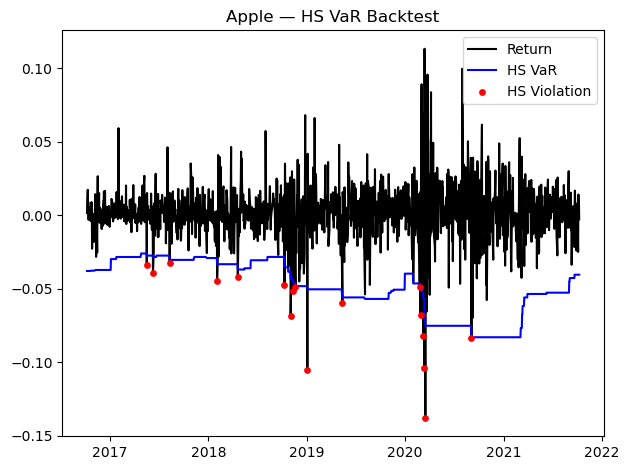

In [88]:
plt.figure()
plt.plot(dates_test, r_test, label="Return", color="black")
plt.plot(dates_test, -VaR_hs, label="HS VaR", color="blue")
plt.scatter(dates_test[hit_hs], r_test[hit_hs],
            color="red", s=15, label="HS Violation", zorder=3)
plt.legend()
plt.title("Apple — HS VaR Backtest")
plt.tight_layout()

save_folder = "../latex/figures"
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, "ECO491_HW6_Q2_Model_1.pdf"))
plt.show()

### Q2: Model 2 — RiskMetrics VaR

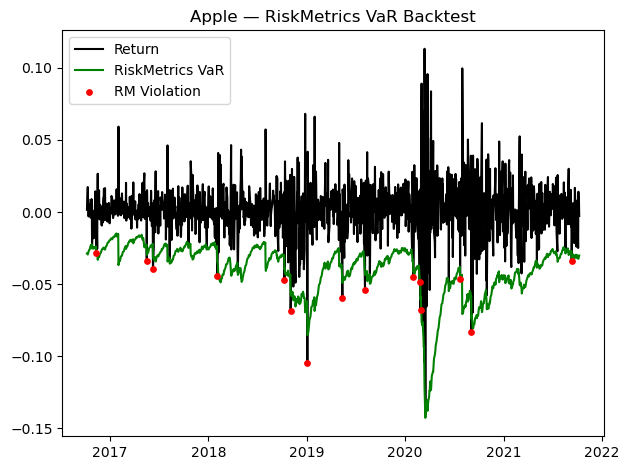

In [89]:
plt.figure()
plt.plot(dates_test, r_test, label="Return", color="black")
plt.plot(dates_test, -VaR_rm, label="RiskMetrics VaR", color="green")
plt.scatter(dates_test[hit_rm], r_test[hit_rm],
            color="red", s=15, label="RM Violation", zorder=3)
plt.legend()
plt.title("Apple — RiskMetrics VaR Backtest")
plt.tight_layout()

save_folder = "../latex/figures"
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, "ECO491_HW6_Q2_Model_2.pdf"))
plt.show()

### Q2: Model 3 — HS violations

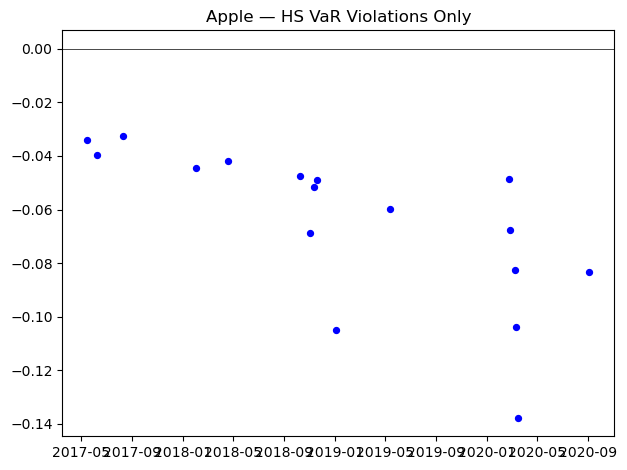

In [90]:
plt.figure()
plt.scatter(dates_test[hit_hs], r_test[hit_hs],
            color="blue", s=18)
plt.axhline(0, color="black", linewidth=0.5)
plt.title("Apple — HS VaR Violations Only")
plt.tight_layout()

save_folder = "../latex/figures"
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, "ECO491_HW6_Q2_Model_3.pdf"))
plt.show()

### Q2: Model 4 — RiskMetrics violations

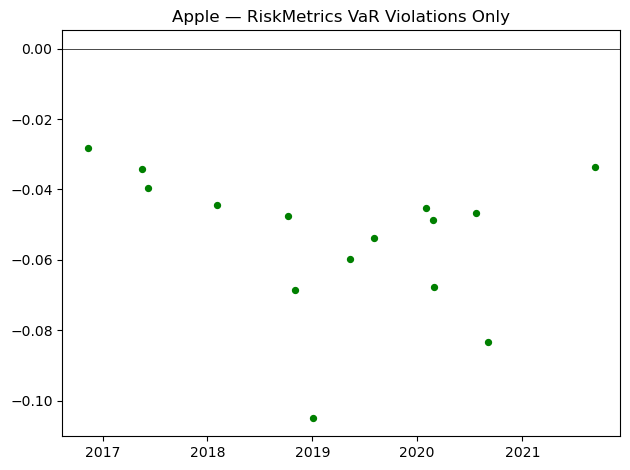

In [91]:
plt.figure()
plt.scatter(dates_test[hit_rm], r_test[hit_rm],
            color="green", s=18)
plt.axhline(0, color="black", linewidth=0.5)
plt.title("Apple — RiskMetrics VaR Violations Only")
plt.tight_layout()

save_folder = "../latex/figures"
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, "ECO491_HW6_Q2_Model_4.pdf"))
plt.show()